# Eksperimen Model Smart Split Bill AI

**Created by: Hami Ahqafi**

Notebook ini membandingkan dua vision-language model OCR-free pada dua foto nota nyata. Output benchmark telah disimpan sehingga hasil tetap terlihat ketika notebook dibuka tanpa menjalankan ulang API.

## Tujuan eksperimen

1. Menguji kemampuan model membaca item, quantity, harga, subtotal, biaya tambahan, dan total bill.
2. Membandingkan hasil pembacaan secara kualitatif.
3. Membandingkan kecepatan inference.
4. Memilih model terbaik untuk prototype Streamlit.

## Model yang dibandingkan

- `Qwen/Qwen3-VL-8B-Instruct:fastest`
- `CohereLabs/aya-vision-32b:fastest`

Keduanya menerima gambar secara langsung dan tidak menggunakan EasyOCR atau PyTesseract.

## Dataset uji — Nota 1

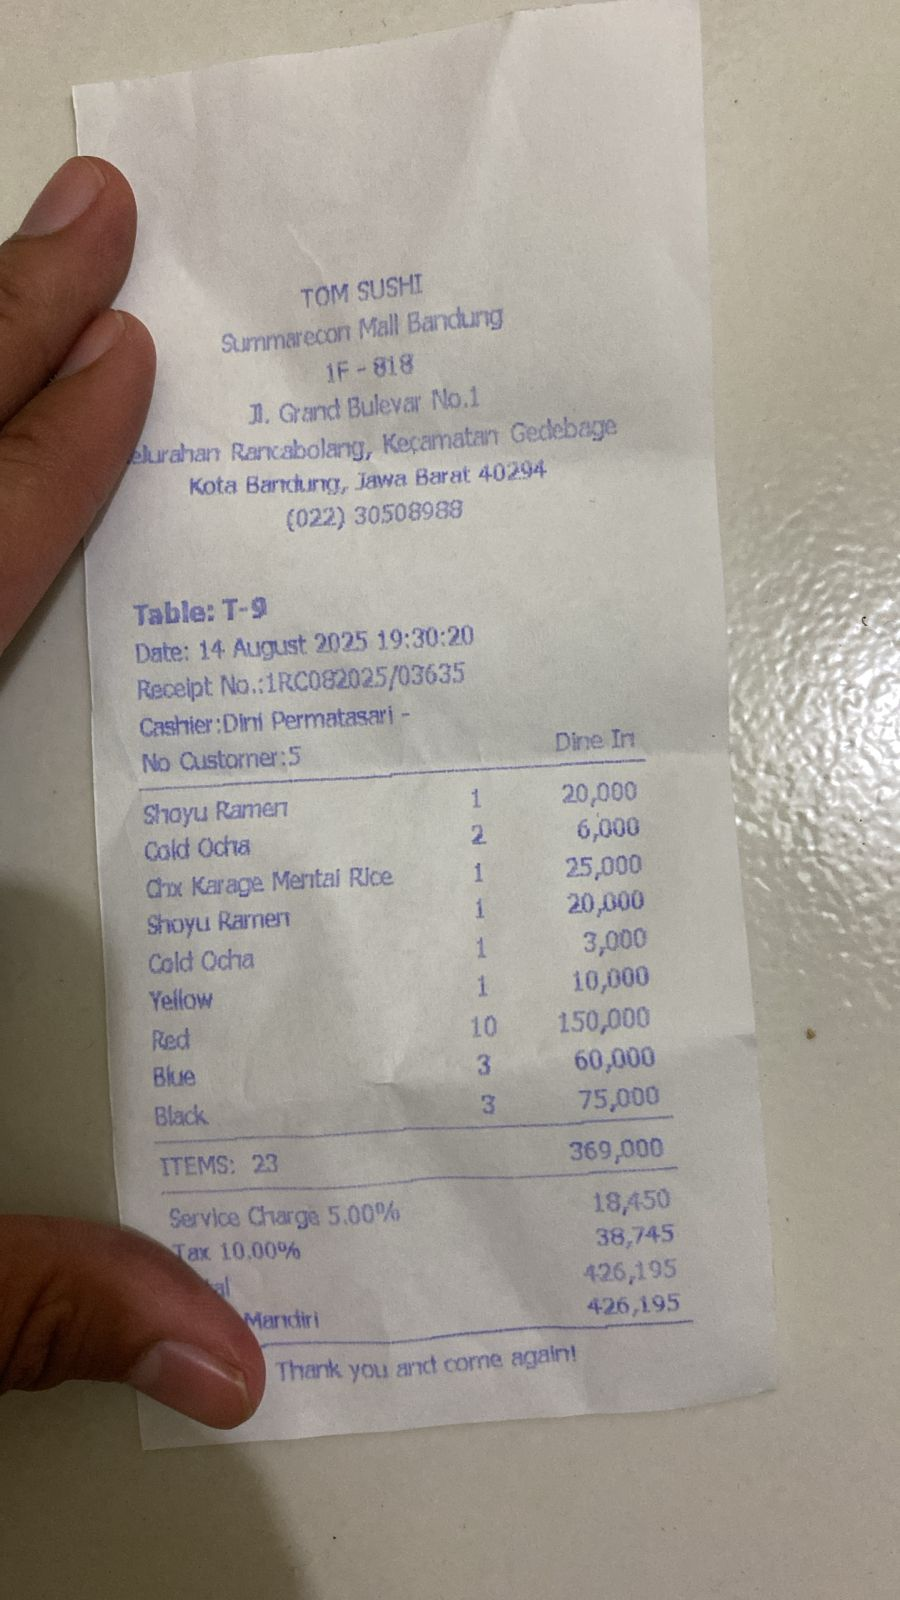

In [1]:
from IPython.display import Image, display
display(Image(filename='../docs/receipts/receipt_1.jpg'))

**Ground truth Nota 1:** 9 baris transaksi, total quantity 23, subtotal Rp369.000, service charge Rp18.450, pajak Rp38.745, dan total Rp426.195.

## Dataset uji — Nota 2

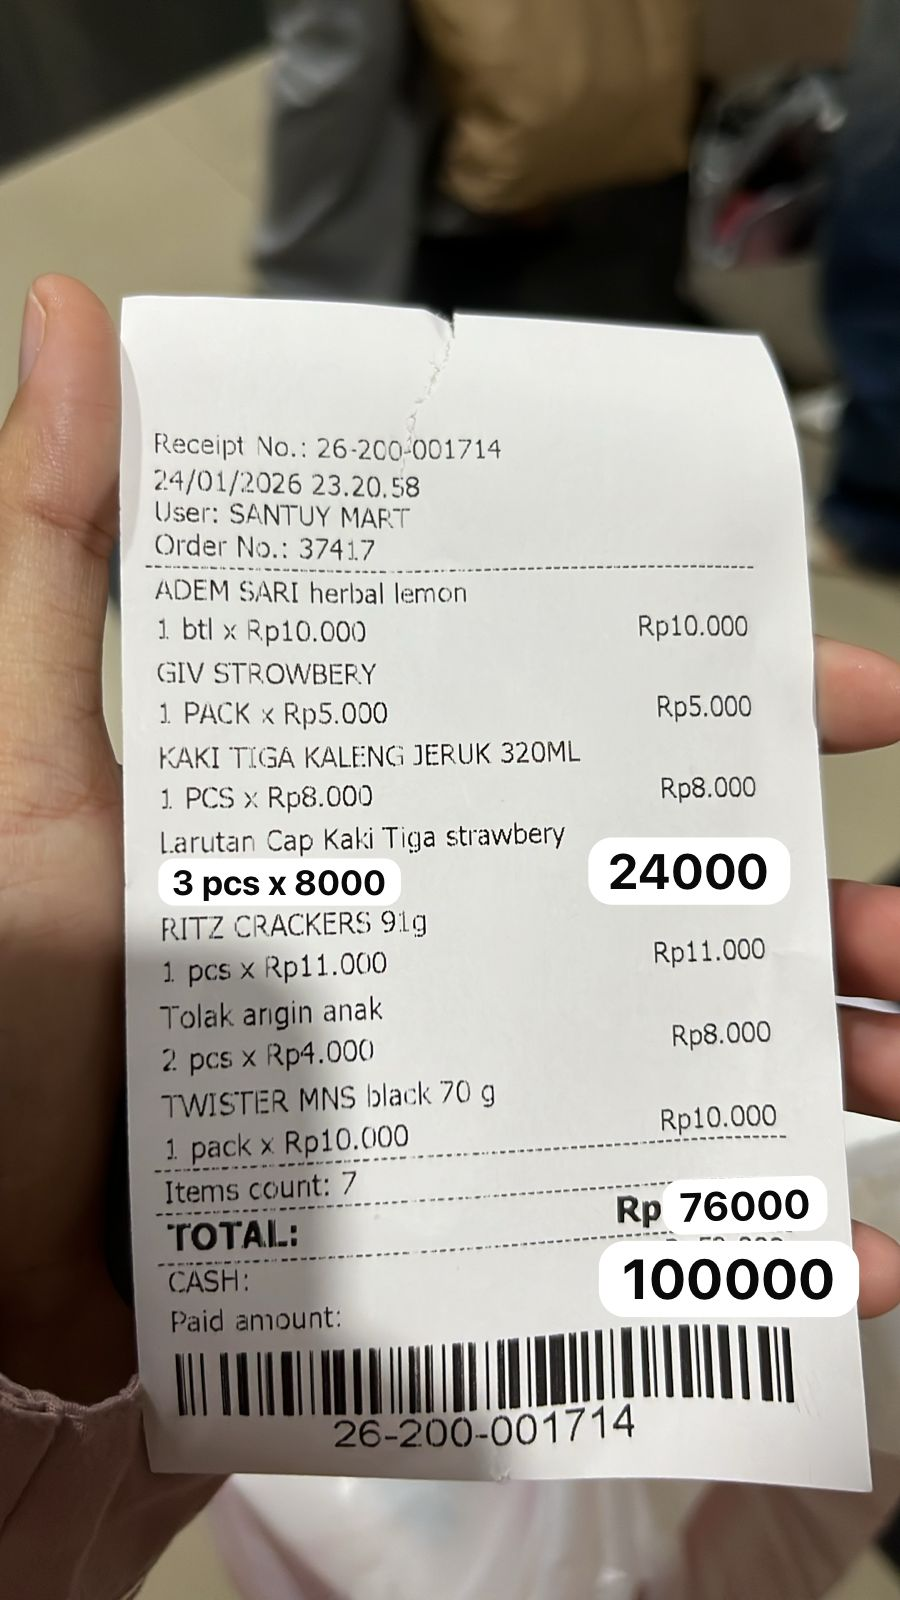

In [2]:
display(Image(filename='../docs/receipts/receipt_2.jpg'))

**Ground truth Nota 2:** 7 jenis item, subtotal dan total Rp76.000, tanpa biaya tambahan. Angka Rp100.000 merupakan paid amount, bukan total bill. Foto memiliki anotasi putih pada beberapa nilai.

## Ground truth terstruktur

In [3]:
import json
ground_truth = json.load(open('../docs/results/ground_truth.json'))
ground_truth

[
  {
    "image": "docs/receipts/receipt_1.jpg",
    "merchant": "TOM SUSHI",
    "items": [
      {
        "name": "Shoyu Ramen",
        "quantity": 1,
        "unit_price": 20000,
        "total": 20000
      },
      {
        "name": "Cold Ocha",
        "quantity": 2,
        "unit_price": 3000,
        "total": 6000
      },
      {
        "name": "Chx Karaage Mentai Rice",
        "quantity": 1,
        "unit_price": 25000,
        "total": 25000
      },
      {
        "name": "Shoyu Ramen",
        "quantity": 1,
        "unit_price": 20000,
        "total": 20000
      },
      {
        "name": "Cold Ocha",
        "quantity": 1,
        "unit_price": 3000,
        "total": 3000
      },
      {
        "name": "Yellow",
        "quantity": 1,
        "unit_price": 10000,
        "total": 10000
      },
      {
        "name": "Red",
        "quantity": 10,
        "unit_price": 15000,
        "total": 150000
      },
      {
        "name": "Blue",
        "quantity": 

## Cara menjalankan benchmark

In [ ]:
# Jalankan dari root repository setelah mengisi HF_TOKEN di .env
!python scripts/benchmark_models.py docs/receipts/receipt_1.jpg docs/receipts/receipt_2.jpg

## Ringkasan hasil inference

In [4]:
import pandas as pd
comparison = pd.read_csv('../docs/results/model_comparison.csv')
comparison

image,model,seconds,items,subtotal,total
receipt_1.jpg,Qwen/Qwen3-VL-8B-Instruct,12.38,9,369000.0,426195.0
receipt_1.jpg,CohereLabs/aya-vision-32b,17.506,10,1845000.0,2121750.0
receipt_2.jpg,Qwen/Qwen3-VL-8B-Instruct,10.971,7,76000.0,100000.0
receipt_2.jpg,CohereLabs/aya-vision-32b,11.045,6,76000.0,76000.0


## Evaluasi terhadap ground truth

In [5]:
evaluation = pd.read_csv('../docs/results/evaluation_summary.csv')
evaluation

image,model,ground_truth_rows,predicted_rows,correct_item_rows,subtotal_correct,charges_correct,total_correct,inference_seconds,main_error
receipt_1.jpg,Qwen3-VL-8B,9,9,8,yes,yes,yes,12.380,Cold Ocha quantity 2 treated Rp6000 as unit price
receipt_1.jpg,Aya Vision 32B,9,10,6,no,no,no,17.506,Column shifting caused prices and subtotal to become item values
receipt_2.jpg,Qwen3-VL-8B,7,7,7,yes,yes,no,10.971,Paid amount Rp100000 interpreted as total bill
receipt_2.jpg,Aya Vision 32B,7,6,5,yes,yes,yes,11.045,Two Kaki Tiga products merged into one row


## Analisis hasil

### Qwen3-VL-8B

- Nota 1: menemukan seluruh 9 baris. Delapan baris tepat; satu `Cold Ocha` salah menempatkan Rp6.000 sebagai harga satuan. Subtotal, service, pajak, dan total terbaca benar.
- Nota 2: menemukan 7/7 item dengan benar, tetapi angka paid amount Rp100.000 dianggap sebagai total bill.
- Rata-rata waktu inference: **11,68 detik**.

### Aya Vision 32B

- Nota 1: terjadi column shifting pada bagian bawah, menghasilkan subtotal dan total yang sangat salah.
- Nota 2: subtotal dan total benar, tetapi dua produk Kaki Tiga digabung menjadi satu sehingga hanya enam baris terdeteksi.
- Rata-rata waktu inference: **14,28 detik**.

In [6]:
qwen_avg = (12.380 + 10.971) / 2
aya_avg = (17.506 + 11.045) / 2
f'Qwen {((aya_avg-qwen_avg)/aya_avg)*100:.1f}% lebih cepat dari Aya'

'Qwen 18.2% lebih cepat dari Aya'

## Model terpilih

**Qwen/Qwen3-VL-8B-Instruct** dipilih karena:

1. Menghasilkan 15 dari 16 baris item dengan benar; Aya 11 dari 16.
2. Lebih stabil pada nota padat dengan banyak kolom.
3. Sekitar 18,2% lebih cepat pada eksperimen ini.
4. Model 8B lebih efisien daripada model pembanding 32B.

Kekeliruan total bill ditangani di aplikasi dengan editor manual dan validasi aritmetika sebelum pembagian dilakukan.

## Kelemahan dan ide improvement

- Tambahkan crop, perspective correction, dan contrast enhancement.
- Terapkan constrained JSON schema.
- Lakukan retry khusus bagian total jika subtotal + charges tidak sesuai total bill.
- Tambahkan confidence score per field.
- Evaluasi dengan dataset nota Indonesia yang lebih besar.
- Bandingkan dengan Donut yang di-fine-tune pada dataset receipt.

## Kesimpulan

Qwen3-VL-8B memberikan trade-off terbaik antara kelengkapan item, stabilitas pembacaan layout, dan latency. Namun hasil model vision tetap perlu diverifikasi pengguna, terutama ketika foto memiliki anotasi, bagian tertutup, atau label pembayaran yang menyerupai total.